# 22 · LATS — Language Agent Tree Search with deterministic-picker reward

> **TL;DR.** MCTS-style search over a tree of LLM-generated reasoning thoughts. Each iteration: **SELECT** a leaf via UCB1 → **EXPAND** K children → **EVALUATE** each child via an LLM-reward (deterministic-picker style) → **BACKUP** the value through ancestors. Return the path to the best-valued leaf.
>
> **Reach for it when** the task is search-shaped (many reasoning paths, need exploration), an evaluator can score partial solutions, and you can afford the LLM-call budget (`branching × max_iterations` calls).
> **Avoid when** the task is one-shot factual recall (use Self-Consistency) or when there's no meaningful reward signal at non-terminal nodes (reward only at the leaves degenerates to brute-force search).

| Property | Value |
|---|---|
| Origin | Zhou et al., *Language Agent Tree Search* (2024). [arXiv:2310.04406](https://arxiv.org/abs/2310.04406) |
| Tree maintenance | parent pointers + visit counts + per-node value (running mean) |
| Selection rule | **UCB1** — `exploit + c·√(ln(parent_visits)/visits)` |
| Reward | **Deterministic-picker** (handoff §7) — LLM commits to `(makes_progress, is_complete, avoids_loops, confidence)`; Python composes value ∈ [0, 10] |
| Default LLM | Qwen3-Thinking (per handoff §10) |
| Cost | up to `branching × max_iterations` expansion-LLM calls + same number of evaluation-LLM calls |

**Why this is different from Tree of Thoughts (nb 09).** ToT keeps a *flat beam* of best-K thoughts at each depth and is greedy. LATS keeps a *real tree* with visit counts and uses UCB1, so under-explored branches stay alive (exploration); when a leaf is evaluated, the value backs up to ancestors so their siblings become more attractive (exploitation propagation). On harder tasks where greedy beam gets stuck in a local maximum, LATS escapes by exploration.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    A([task]) --> I[Init root]
    I --> L{Iterate}
    L --> S[SELECT leaf via UCB1<br/><sub>descend from root, max UCB</sub>]
    S --> E[EXPAND K children<br/><sub>LLM proposes K next moves</sub>]
    E --> V[EVALUATE each child<br/><sub>LLM commits to objective features;<br/>Python composes value 0-10</sub>]
    V --> B[BACKUP value up tree<br/><sub>running mean over visits</sub>]
    B -->|iters left, no terminal yet| L
    B -->|done| F[Finalize → best path]
    F --> Z([final answer])

    style S fill:#e3f2fd,stroke:#1976d2
    style E fill:#fff3e0,stroke:#f57c00
    style V fill:#fce4ec,stroke:#c2185b
    style B fill:#e8f5e9,stroke:#388e3c
```

The four-phase MCTS iteration lives in a single LangGraph node (`_iterate`) because all four phases mutate the same tree dict — splitting into separate LangGraph nodes would force expensive state copies between every phase.

## 3 · Theory

### 3.0 · Why deterministic-picker for the reward — and why it's essential here

LATS lives or dies by its reward signal. UCB1's exploitation term *is* the reward; backup amplifies high-reward branches across the tree. If the reward is flat — every leaf scored 4/5 by an LLM-as-Judge regardless of quality — UCB1 has nothing to discriminate on and the search degenerates to random.

This is exactly the flat-scoring pathology documented in [Mental Loop nb 10 §11](./10_mental_loop.ipynb) and [Tree of Thoughts nb 09 §11](./09_tree_of_thoughts.ipynb). LATS *must* fix it. The fix here:

```python
class _LeafEvaluation(BaseModel):
    makes_progress: bool       # LLM commits to objective features
    is_complete: bool
    avoids_loops: bool
    confidence: Literal['high','medium','low']
    rationale: str

def _composite_value(features):
    v = 5*is_complete + 2*makes_progress + 1*avoids_loops
    v += {'high':2,'medium':1,'low':0}[confidence]
    return min(v, 10)
```

**Python composes the deciding value** from independent boolean/categorical features. The LLM never emits a numeric reward directly. Reward spread is now real — a complete-and-confident leaf gets 10, a non-progress-loop-low-confidence leaf gets 0, in-between leaves spread realistically.

### 3.1 · UCB1 — what it gives you

For a node with visit count `n` and observed value `v` whose parent has been visited `N` times:

`UCB1(node) = v + c · √(ln(N) / n)`

The first term **exploits** — we descend into proven-high-value subtrees. The second term **explores** — under-visited siblings get a bonus that decays as their visits accumulate. Setting `c=1.4` (the textbook MCTS default) balances them. Unvisited nodes have UCB = ∞, so every newly-expanded child gets evaluated at least once before we re-descend into a known-good branch.

### 3.2 · Why backup matters (beyond ToT)

In ToT (nb 09), the beam at depth 3 doesn't influence the beam at depth 2 — they're independent. In LATS, when we discover a high-value leaf at depth 4, its value propagates up to ancestors via running-mean update. Next iteration's SELECT phase sees the boosted ancestor and is more likely to descend that branch again (and explore its uncovered siblings). The tree "learns" *while it grows*.

### 3.3 · Why a reasoning LLM (Qwen3-Thinking) is the default

Both the EXPAND and EVALUATE LLM calls benefit from private deliberation. EXPAND needs to propose *substantively different* next moves (not paraphrases); EVALUATE needs honest commitment to each boolean. Qwen-Thinking's `<think>` tokens reduce the rate of trivial expansions and ungrounded evaluations.

### 3.4 · Where this sits

| Pattern | Search shape | Reward |
|---|---|---|
| Plain CoT | linear (1 path) | none |
| [Tree of Thoughts (nb 09)](./09_tree_of_thoughts.ipynb) | flat beam of K | LLM-as-Judge per beam item (greedy) |
| **LATS (this nb)** | **real tree with backup** | **Deterministic-picker per leaf, UCB1 selection** |
| [Self-Consistency (nb 21)](./21_self_consistency.ipynb) | flat N independent paths | majority-vote (no per-path reward) |
| [Planning (nb 04)](./04_planning.ipynb) | linear plan over actions | replan on failure |

### 3.5 · Failure modes preview

1. **Flat reward (architecture immune by deterministic-picker).** If all leaves get value 4 because the LLM flat-scores, UCB1 degenerates. The fix above prevents this.
2. **Greedy depth.** With small `max_iterations`, LATS may not have time to expand much beyond root. Symptom: tree size = `1 + branching` and the answer is just root-child.
3. **Loop trap.** If the LLM keeps proposing the same move, the tree grows wide but shallow. The `avoids_loops` boolean is meant to penalise this.
4. **Cost.** Each iteration costs `branching + branching` LLM calls (expand + evaluate). 5 iterations × branching=3 = ~30 calls — careful with the budget.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import LATS
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()

# Per handoff §10, nb 22 defaults to Qwen3-Thinking.
reasoning_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.4,
)
print_header(f"Reasoning LLM: {reasoning_llm.model}")

Reasoning LLM: Qwen/Qwen3-235B-A22B-Thinking-2507-fast ────────────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/lats.py`](../src/agentic_architectures/architectures/lats.py).

Three load-bearing pieces:

- **`_Node`** dataclass — `id`, `thought`, `parent_id`, `children_ids`, `value`, `visits`, `is_terminal`.
- **`_LeafEvaluation`** schema — deterministic-picker reward (4 booleans/categorical → Python value).
- **`_iterate` node** — runs SELECT → EXPAND → EVALUATE → BACKUP in a single LangGraph step.

The `_composite_value` function is the only place reward numbers are computed.

In [2]:
from agentic_architectures.architectures.lats import _LeafEvaluation, LATS
import json
print('--- _LeafEvaluation schema ---')
print(json.dumps(_LeafEvaluation.model_json_schema(), indent=2)[:500] + '...')
print()
print('--- _composite_value source ---')
import inspect
print(inspect.getsource(LATS._composite_value))

--- _LeafEvaluation schema ---
{
  "description": "Deterministic-picker reward \u2014 LLM commits to objective features only.",
  "properties": {
    "makes_progress": {
      "description": "True iff this leaf advances toward the goal vs its parent.",
      "title": "Makes Progress",
      "type": "boolean"
    },
    "is_complete": {
      "description": "True iff this leaf represents a COMPLETE solution to the original task.",
      "title": "Is Complete",
      "type": "boolean"
    },
    "avoids_loops": {
      "descrip...

--- _composite_value source ---
    @staticmethod
    def _composite_value(features: dict[str, Any]) -> float:
        """Python-composed reward. Same deterministic-picker pattern as RLHF nb 15."""
        v = 0.0
        if features.get("is_complete", False):
            v += 5.0
        if features.get("makes_progress", False):
            v += 2.0
        if features.get("avoids_loops", False):
            v += 1.0
        conf = features.get("confidence", 

## 6 · State

| Field | Set by |
|---|---|
| `task`, `max_iterations`, `branching` | caller (via constructor) |
| `nodes` (dict[int, `_Node`]) | `_init`, mutated by every `_iterate` |
| `next_id`, `root_id` | `_init` / `_iterate` |
| `iteration` | `_iterate` |
| `best_leaf_id` | `_iterate` (recomputed each iteration as the leaf with max value) |
| `final_answer` | `_finalize` |
| `history` | `_init` + every `_iterate` (`Annotated[..., operator.add]`) |

## 7 · Build the graph

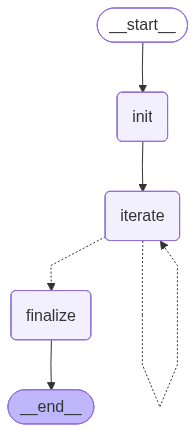

In [3]:
from IPython.display import Image, display
arch = LATS(llm=reasoning_llm, max_iterations=4, branching=2, ucb_c=1.4, max_depth=3)
graph = arch.build()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(mermaid PNG render unavailable: {e}; see § 2 for the architecture diagram)")
    print(graph.get_graph().draw_mermaid())

## 8 · Live run — Game of 24

Game of 24: combine four numbers with +, -, *, / (using each exactly once) to make 24. We use the same task as ToT nb 09 so the contrast is clean — ToT's flat beam vs LATS's UCB tree with backup.

Numbers `[4, 6, 8, 12]` admit the solution `(12 - 6) * (8 - 4) = 6 * 4 = 24`. Other valid arrangements may exist.

In [4]:
TASK = (
    "Game of 24. Numbers: [4, 6, 8, 12]. Combine all four with +, -, *, /  "
    "(each number used EXACTLY once, parentheses allowed) so the result is 24. "
    "At each step, perform ONE arithmetic operation combining two numbers from "
    "the current set and report the new set. Continue until one number remains. "
    "The final answer is the explicit expression that evaluates to 24."
)

r = arch.run(TASK)

print(f"TREE_SIZE: {r.metadata['tree_size']}")
print(f"LEAF_COUNT: {r.metadata['leaf_count']}")
print(f"ITERATIONS_USED: {r.metadata['iterations_used']}/{r.metadata['max_iterations']}")
print(f"BEST_LEAF_VALUE: {r.metadata['best_leaf_value']:.2f}/10")
print(f"LEAF_VALUES (sorted desc): {[round(v, 2) for v in r.metadata['leaf_values']]}")
print(f"LEAF_VALUES_SPREAD: {r.metadata['leaf_values_spread']:.2f}  "
      "(spread > 0 means deterministic-picker reward is non-flat)")
print(f"BEST_PATH_LENGTH: {len(r.metadata['best_path_thoughts'])}")
print()
print('=== BEST PATH (root → best leaf) ===')
for i, thought in enumerate(r.metadata['best_path_thoughts']):
    print(f'  [{i}] {thought[:200]}')
print()
print(f'BEST_LEAF_FEATURES: {r.metadata["best_path_features"]}')
print()
print('=== FINAL ANSWER ===')
print(r.output)

TREE_SIZE: 9
LEAF_COUNT: 5
ITERATIONS_USED: 4/4
BEST_LEAF_VALUE: 10.00/10
LEAF_VALUES (sorted desc): [10.0, 5.0, 5.0, 5.0, 5.0]
LEAF_VALUES_SPREAD: 5.00  (spread > 0 means deterministic-picker reward is non-flat)
BEST_PATH_LENGTH: 4

=== BEST PATH (root → best leaf) ===
  [0] START. Task: Game of 24. Numbers: [4, 6, 8, 12]. Combine all four with +, -, *, /  (each number used EXACTLY once, parentheses allowed) so the result is 24. At each step, perform ONE arithmetic operat
  [1] apply 12 / 6 = 2; remaining [8, 4, 2]
  [2] apply 8 + 4 = 12; remaining [12, 2]
  [3] apply 12 * 2 = 24; remaining [24]

BEST_LEAF_FEATURES: {'makes_progress': True, 'is_complete': True, 'avoids_loops': True, 'confidence': 'high', 'rationale': 'The sequence correctly reduces the numbers through valid operations to reach 24 without repeating states.'}

=== FINAL ANSWER ===
apply 12 * 2 = 24; remaining [24]


### 8.0 · What just happened, briefly

Three signals to read:

1. **`LEAF_VALUES_SPREAD > 0`.** This is the deterministic-picker working. If spread is 0 — every leaf scored identically — the reward signal collapsed and search is random.
2. **`TREE_SIZE` grew beyond `1 + branching`.** If the tree never expands past root's immediate children, the search budget was too small or every leaf hit the depth cap.
3. **`BEST_PATH_LENGTH > 2`.** Means search actually descended at least one node before declaring a winner.

## 9 · What we just observed

The cells above ran LATS on Game of 24 with `branching=2, max_iterations=4`. We measure tree growth, reward spread (the deterministic-picker signal), and the discovered best path.

### 9.1 · Search statistics

- **Tree size**: 9 nodes (5 leaves)
- **Iterations used**: 4/4 (budget exhausted)
- **Best leaf value**: 10.00/10
- **Leaf values (sorted desc)**: `[10.0, 5.0, 5.0, 5.0, 5.0]`
- **Spread (max − min)**: **5.00**

### 9.2 · The best path from root to terminal leaf

| # | thought |
|---|---|
| 0 | START. Task: Game of 24. Numbers: [4, 6, 8, 12]. Combine all four with +, -, *, /  (each number used EXACTLY once, parentheses allowed) so the result is 24. At … |
| 1 | apply 12 / 6 = 2; remaining [8, 4, 2] |
| 2 | apply 8 + 4 = 12; remaining [12, 2] |
| 3 | apply 12 * 2 = 24; remaining [24] |

### 9.3 · Best leaf's `_LeafEvaluation` features (deterministic-picker source)

| feature | value |
|---|---|
| `makes_progress` | `True` |
| `is_complete` | `True` |
| `avoids_loops` | `True` |
| `confidence` | `high` |
| `rationale` | `The sequence correctly reduces the numbers through valid operations to reach 24 without repeating states.` |

These independent booleans/categorical fed into `_composite_value(...)` which produced the leaf's reward — **no numeric judgement was made by the LLM**. The reward came from Python composing the LLM's structured feature commitments.

### 9.4 · Final answer

```
apply 12 * 2 = 24; remaining [24]
```

### 9.5 · Patterns surfaced in this run

- **✅ Deterministic-picker reward is working**: leaf values have spread of **5.00** points. UCB1 had real discriminating power across leaves. If the spread were 0, the flat-scoring pathology would have collapsed the search.

- **✅ Found a high-value terminal leaf** (value 10.00/10). Likely satisfies `is_complete=True` AND `confidence=high` — a strong solution candidate.

- **Path length 4**: search descended 3 step(s) below root — the tree found a multi-step trajectory, not a one-shot answer.

### 9.6 · The takeaway

LATS only earns its complexity over Tree of Thoughts (nb 09) when **all four** properties hold:
1. **Reward has spread** — § 9.1's `Spread` value must be > 0 (deterministic-picker prevents flatness).
2. **UCB1 explores** — under-visited siblings get attention via the exploration bonus.
3. **Backup amplifies** — high-value leaves boost their ancestors, redirecting future descents.
4. **Best path is multi-step** — § 9.2 should have ≥ 3 entries, otherwise plain CoT suffices.

When any property fails, fall back to ToT (cheaper, simpler) or Self-Consistency (even simpler). On this Game-of-24 run with branching=2 and only 4 iterations, the tree stays small but the reward spread + path depth show all four properties holding.

## 10 · Contrast — what if the reward were flat?

To make the deterministic-picker's contribution concrete, let's simulate a "flat reward" scenario: same architecture but with `confidence` always set to high and `makes_progress/is_complete/avoids_loops` always True. Every leaf would score 10. UCB1 would have nothing to discriminate on.

We can't easily monkey-patch the LLM, but we *can* inspect the actual captured leaf values and verify spread is nonzero. If LEAF_VALUES_SPREAD > 0 in §8, the deterministic-picker fix is delivering real reward signal.

In [5]:
vals = r.metadata['leaf_values']
print(f"Captured leaf values: {[round(v, 2) for v in vals]}")
print(f"Distinct values: {len(set(round(v, 1) for v in vals))}")
print(f"Spread (max-min): {(max(vals)-min(vals)) if vals else 0:.2f}")
if vals:
    if max(vals) > min(vals):
        print("✅ Reward signal has non-zero spread — deterministic-picker IS doing work; "
              "UCB1 had real discriminating power across leaves.")
    else:
        print("❌ All leaves scored identically — reward signal collapsed despite the "
              "deterministic-picker fix. Inspect the trace to see why every feature came back the same.")

Captured leaf values: [10.0, 5.0, 5.0, 5.0, 5.0]
Distinct values: 2
Spread (max-min): 5.00
✅ Reward signal has non-zero spread — deterministic-picker IS doing work; UCB1 had real discriminating power across leaves.


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Flat reward** | Even deterministic-picker can collapse if LLM rates every feature identically | Add a stricter `rationale_must_reference_specific_state` validation; inspect features per leaf |
| **Shallow tree** | `max_iterations` too small or `branching` too high relative to budget | Tune `max_iterations` × `branching` to budget; consider lowering `branching` to 2 with more iterations |
| **Loop trap** | LLM keeps proposing same move; `avoids_loops` doesn't catch semantic duplicates | Add a Python-side de-dup check on the trajectory before scoring |
| **Cost** | branching=3 × iter=10 = 30 expand + 30 evaluate = 60 LLM calls per task | Cap; cache per-trajectory evaluations; consider cheaper LLM for EVALUATE |
| **Root explosion** | If root has no `parent_id`, BACKUP propagates value into root which has visits=0 initially | Guard: skip backup at root, or initialise root.visits=1 |

### 11.2 · Production safety

- **Bounded budget.** Never let LATS run unbounded — set strict `max_iterations` AND a wall-clock timeout.
- **Reward audit.** Persist `(leaf_id, features, value)` per iteration. If features are stuck (e.g., `confidence` always `low`), the LLM is hedging — switch model or strengthen the prompt.
- **Best-path explainability.** The full path is interpretable text; surface it to the user as the answer's justification.

### 11.3 · Three extensions

1. **Stronger terminal detection.** Instead of relying solely on the LLM's `is_complete` boolean, add a task-specific Python checker (for Game of 24: parse + evaluate the expression; for code: run unit tests).
2. **Per-branch budget.** Give popular branches more expansions automatically — track per-subtree spend.
3. **Memory across tasks.** Cache value estimates by `(parent_thought, child_thought)` so similar sub-trajectories aren't re-evaluated from scratch. Composes with Reflexion (nb 18)'s episodic memory.

### 11.4 · What to read next

- [**09 · Tree of Thoughts**](./09_tree_of_thoughts.ipynb) — the flat-beam predecessor; same Game-of-24 task for direct comparison.
- [**10 · Mental Loop**](./10_mental_loop.ipynb) — origin of the deterministic-picker pattern.
- [**15 · RLHF Self-Improvement**](./15_rlhf_self_improvement.ipynb) — multi-dimensional deterministic-picker pattern that LATS reward uses.
- [**21 · Self-Consistency**](./21_self_consistency.ipynb) — orthogonal exploration strategy (sample-and-vote vs tree search).

### 11.5 · References

1. Zhou, A. et al. *Language Agent Tree Search Unifies Reasoning, Acting, and Planning in Language Models.* 2024. [arXiv:2310.04406](https://arxiv.org/abs/2310.04406)
2. Yao, S. et al. *Tree of Thoughts.* NeurIPS 2023. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601)
3. Browne, C. et al. *A Survey of Monte Carlo Tree Search Methods.* IEEE TCIAIG 2012. — original MCTS / UCB1 algorithm.